### Libraries

In [1]:
import pandas as pd
import pandas as pd
import tensorflow as tf

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import accuracy_score, auc, roc_curve
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Setup

In [14]:
train_df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\train_churn_dataset.csv')
val_df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\val_churn_dataset.csv')
test_df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\test_churn_dataset.csv')

In [ ]:
X_train = train_df.drop(columns=['Churn'])
y_train = train_df['Churn']

In [16]:
X_val = val_df.drop(columns=['Churn'])
y_val = val_df['Churn']

In [18]:
X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']

In [19]:
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

# Distribution of labels in the training set
train_labels = y_train.values

print("\nTraining set label distribution:")
print(pd.Series(train_labels).value_counts(normalize=True))

Training set size: 314599
Validation set size: 67414
Test set size: 67415

Training set label distribution:
1    0.500002
0    0.499998
Name: proportion, dtype: float64


### Model Training

In [20]:
# Number of input features
input_dim = X_train.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')      # Binary classification
])

c:\Users\User\ODL_Labs\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [22]:
# Set up early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [23]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,                      # Train for 30 epochs
    batch_size=32,                  # 32 samples per batch
    validation_data=(X_val, y_val), # Monitor on validation set
    callbacks=[early_stop],          # Use early stopping
    verbose=1                       # Show progress bar
)

Epoch 1/30


9832/9832 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - accuracy: 0.9114 - loss: 0.2536 - val_accuracy: 0.9216 - val_loss: 0.2225
Epoch 2/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9224 - loss: 0.2231 - val_accuracy: 0.9231 - val_loss: 0.2168
Epoch 3/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.9232 - loss: 0.2195 - val_accuracy: 0.9231 - val_loss: 0.2142
Epoch 4/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9234 - loss: 0.2166 - val_accuracy: 0.9238 - val_loss: 0.2119
Epoch 5/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9239 - loss: 0.2143 - val_accuracy: 0.9245 - val_loss: 0.2089
Epoch 6/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 10s 980us/step - accuracy: 0.9243 - loss: 0.2129 - val_accuracy: 0.9242 - val_loss: 0.2074
Epoch 7/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 9s 912us/step - accuracy: 0.9246 - loss: 0.2117 - val_accuracy: 0.9248 - val_loss: 0.2055
Epoch 8/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 9s 902us/step - accuracy: 0.9247 - loss: 0.2104 -

### Model Evaluation

In [24]:
# Test the model on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

2107/2107 ━━━━━━━━━━━━━━━━━━━━ 1s 394us/step


In [25]:
# Classification report
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

accuracy = accuracy_score(y_test, y_pred)
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"CLASSIFICATION REPORT:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

CLASSIFICATION REPORT:
Accuracy: 0.9261291997329971
Precision: 0.8745859955665667
Recall: 0.9949268697896579
F1-score: 0.9308832509853995


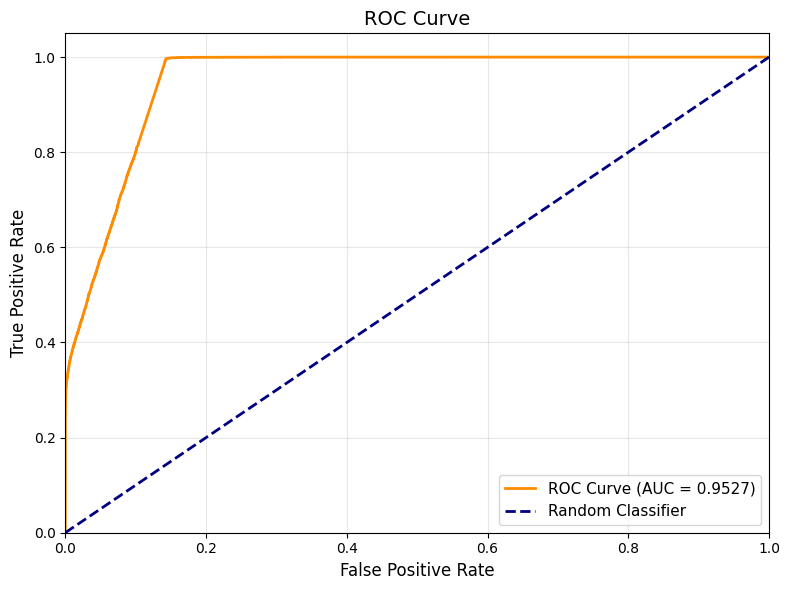

AUC Score: 0.9527


In [26]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('roc_auc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

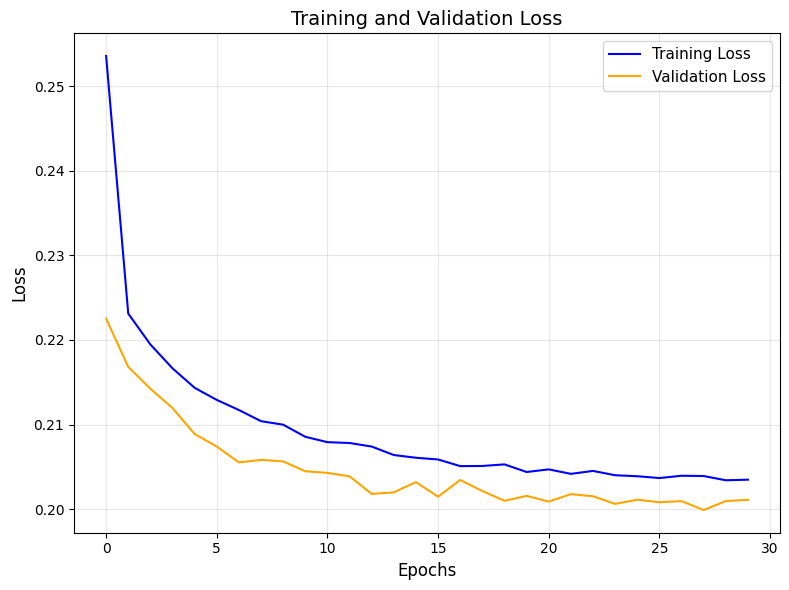

In [27]:
# Training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()


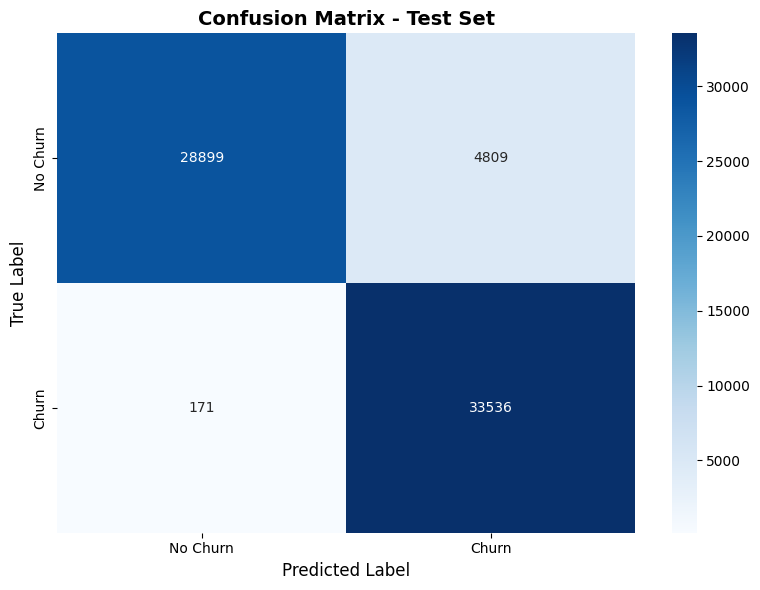

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
 
# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()